In [195]:
from pathlib import Path
import random

import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats import power

import matplotlib.pylab as plt

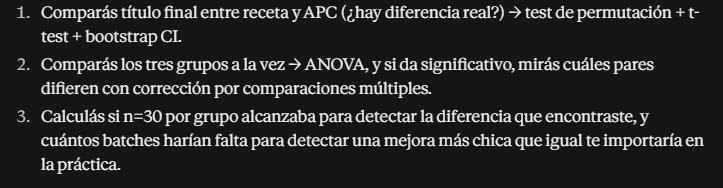

# FUNCIONES

In [221]:
def plot_hist(sim_var, obs_var, x_px=0, y_px=0):

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.hist(sim_var, bins=11, rwidth=0.9, edgecolor='black')
    ax.axvline(x = obs_var, color='black', lw=2)
    ax.text(x_px, y_px, 'Observed\nvariance', bbox={'facecolor':'white'})
    ax.set_xlabel('Variance')
    ax.set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

# Programa

In [122]:
DATA = Path('..') / 'data' / 'Mendeley_data'
pensim = pd.read_csv(DATA / "100_Batches_IndPenSim_Statistics.csv")
pensim

,Batch ref,Penicllin_harvested_during_batch(kg),Penicllin_harvested_end_of_batch (kg),Penicllin_yield_total (kg),Fault ref(0-NoFault 1-Fault)
0,1,1066400.0,1720000.0,2786400.0,0
1,2,985910.0,1340100.0,2326000.0,0
2,3,1416100.0,1259200.0,2675300.0,0
3,4,815700.0,1071000.0,1886700.0,0
4,5,1128500.0,2434400.0,3562900.0,0
...,...,...,...,...,...
95,96,1141500.0,2453400.0,3595000.0,1
96,97,1439400.0,2454900.0,3894300.0,1
97,98,799760.0,930830.0,1730600.0,1
98,99,388650.0,502180.0,890830.0,1


In [123]:
pensim.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Batch ref                              100 non-null    int64  
 1   Penicllin_harvested_during_batch(kg)   100 non-null    float64
 2   Penicllin_harvested_end_of_batch (kg)  100 non-null    float64
 3   Penicllin_yield_total (kg)             100 non-null    float64
 4   Fault ref(0-NoFault 1-Fault)           100 non-null    int64  
dtypes: float64(3), int64(2)
memory usage: 4.0 KB


## Colocamos una etiqueta de a que batch corresponde cada fila

In [124]:
def categories(x):
    if x['Batch ref'] <= 30:
        x['cat'] = 'fix'
    elif 30 < x['Batch ref'] <= 60:
        x['cat'] = 'person'
    elif 60 < x['Batch ref'] <= 90:
        x['cat'] = 'machine'
    else:
        x['cat'] = 'ind_error'

    return x

In [125]:
# df['cat'] = pd.cut(df['Batch ref'], bins=[-float('inf'), 30, 60, 90, float('inf')],   labels=['fix', 'person', 'machine', 'ind_error'])


In [126]:
pensim_mod = pensim.apply(categories, axis=1)

In [127]:
pensim_mod.groupby(by='cat').mean()/10**6

,Batch ref,Penicllin_harvested_during_batch(kg),Penicllin_harvested_end_of_batch (kg),Penicllin_yield_total (kg),Fault ref(0-NoFault 1-Fault)
cat,,,,,
fix,0.000016,1.141227,1.771529,2.912750,0.000000
ind_error,0.000096,1.018903,1.581268,2.600203,0.000001
machine,0.000076,1.181123,2.303150,3.484283,0.000000
person,0.000046,1.033557,1.799544,2.833113,0.000000


# Diferencia entre medias (t-test). Boostrap y calculo de IC.

### Permutation Test

In [178]:
x = pensim_mod.drop(columns=['Batch ref', 'Penicllin_harvested_during_batch(kg)', 'Penicllin_harvested_end_of_batch (kg)', 'Penicllin_harvested_end_of_batch (kg)', 'Fault ref(0-NoFault 1-Fault)']).rename(columns={'Penicllin_yield_total (kg)': 'pen_total'})

x = x[(x['cat'] != 'ind_error') & (x['cat'] != 'fix')]

x.head(), x.tail()

(    pen_total     cat
 30  1890100.0  person
 31  4196000.0  person
 32  3294100.0  person
 33  2066400.0  person
 34  3537900.0  person,
     pen_total      cat
 85  3320800.0  machine
 86  3470600.0  machine
 87  3059300.0  machine
 88  3291400.0  machine
 89  3464200.0  machine)

In [179]:
x.groupby('cat').mean()

,pen_total
cat,
machine,3.484283e+06
person,2.833113e+06


* Quiero ver si las diferencias entre medias son significativas para un alpha=0.05

In [181]:
x.head(3)

,pen_total,cat
30,1890100.0,person
31,4196000.0,person
32,3294100.0,person


In [223]:
obs_dif_mean = (-x.groupby('cat').mean().iloc[1] + x.groupby('cat').mean().iloc[0])['pen_total']
obs_dif_mean

np.float64(651170.0)

In [270]:
np.random.seed(42)

def permutation_test(x):
    x = x.copy()
    x['pen_total'] = np.random.permutation(x['pen_total'].values)

    # es la diferencia entre medias de person (1) y machine (0)
    dif_mean = (-x.groupby('cat').mean().iloc[1] + x.groupby('cat').mean().iloc[0])['pen_total']
    return dif_mean

sim_dif_mean = pd.Series([permutation_test(x) for _ in range(5000)])

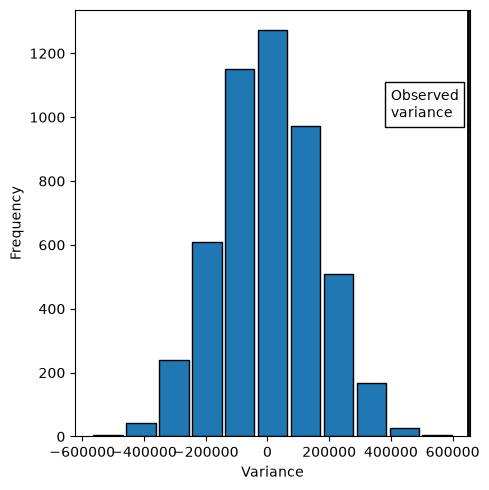

In [271]:
plot_hist(sim_dif_mean, obs_dif_mean, y_px=1000, x_px=400000)

In [272]:
p_perm_test = (sim_dif_mean >= obs_dif_mean).mean()
p_perm_test

np.float64(0.0)

In [273]:
print(f'p-value: {p_perm_test:.10f}')

p-value: 0.0000000000


* Vemos que el p value es muchisimo mas chico que **alpha = 0.05** con lo cual rechazamos H0. Estadisticamente podemos decir que las medias son diferentes para un **alpha=0.05**.

### Boostrap e IC

In [231]:
x.shape

(60, 2)

In [230]:
x.head()

,pen_total,cat
30,1890100.0,person
31,4196000.0,person
32,3294100.0,person
33,2066400.0,person
34,3537900.0,person


* Quiero cuantificar la diferencia de medias con un IC de 95%

In [242]:
def boostrap_IC(x, n=3000, alpha=0.05):

    person = x.loc[x['cat'] == 'person', 'pen_total']
    machine = x.loc[x['cat'] == 'machine', 'pen_total']

    dif_mean_list = []

    for _ in range(n):
        p_resample = person.sample(n=len(person), replace=True)
        m_resample = machine.sample(n=len(machine), replace=True)
        dif_mean_list.append(m_resample.mean() - p_resample.mean())

    dif_means = pd.Series(dif_mean_list)

    IC_low, IC_high = dif_means.quantile([alpha/2, 1 - alpha/2])

    return dif_means, (IC_low, IC_high)

In [255]:
boostrap_intervalos = boostrap_IC(x)

In [279]:
print(f'La media de la diferencia es {boostrap_intervalos[0].mean()}')
print(f'La diferencia entre medias con un IC de 95% es ({boostrap_intervalos[1][0]} - {boostrap_intervalos[1][1]})')

La media de la diferencia es 644263.4988888889
La diferencia entre medias con un IC de 95% es (391511.9166666667 - 894414.083333333)


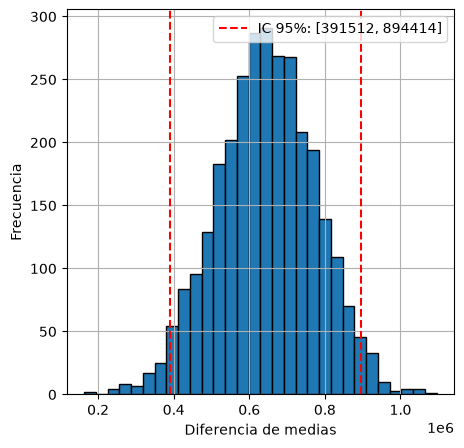

In [258]:
fig, ax = plt.subplots(figsize=(5, 5))
boostrap_intervalos[0].hist(ax=ax, bins=30, edgecolor='black')
ax.axvline(boostrap_intervalos[1][0], color='red', linestyle='--', label=f'IC 95%: [{boostrap_intervalos[1][0]:.0f}, {boostrap_intervalos[1][1]:.0f}]')
ax.axvline(boostrap_intervalos[1][1], color='red', linestyle='--')
ax.set_xlabel('Diferencia de medias')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.show()

### Me queda calcular el t-test con formula. A ver si se acerca al p-value calculado

In [259]:
from scipy import stats

person = x.loc[x['cat'] == 'person', 'pen_total']
machine = x.loc[x['cat'] == 'machine', 'pen_total']

t_stat, p_value = stats.ttest_ind(machine, person, equal_var=False)  # Welch's t-test
print(f't-stat: {t_stat:.4f}, p-value: {p_value:.6f}')


t-stat: 4.7782, p-value: 0.000023


# ANOVA

## Quiero ver si la penicilina total recolectada entre los grupos puede ser una diferencia debida unicamente al azar o si los metodos realmente tienen consecuencias diferentes

### Primero hacemos un permutation test

In [128]:
pensim_mod.head()

,Batch ref,Penicllin_harvested_during_batch(kg),Penicllin_harvested_end_of_batch (kg),Penicllin_yield_total (kg),Fault ref(0-NoFault 1-Fault),cat
0,1.0,1066400.0,1720000.0,2786400.0,0.0,fix
1,2.0,985910.0,1340100.0,2326000.0,0.0,fix
2,3.0,1416100.0,1259200.0,2675300.0,0.0,fix
3,4.0,815700.0,1071000.0,1886700.0,0.0,fix
4,5.0,1128500.0,2434400.0,3562900.0,0.0,fix


In [129]:
pensim_mod_permt = pensim_mod.drop(columns=['Batch ref', 'Penicllin_harvested_during_batch(kg)', 'Penicllin_harvested_end_of_batch (kg)', 'Penicllin_harvested_end_of_batch (kg)', 'Fault ref(0-NoFault 1-Fault)']).rename(columns={'Penicllin_yield_total (kg)': 'pen_total'})

pensim_mod_permt

,pen_total,cat
0,2786400.0,fix
1,2326000.0,fix
2,2675300.0,fix
3,1886700.0,fix
4,3562900.0,fix
...,...,...
95,3595000.0,ind_error
96,3894300.0,ind_error
97,1730600.0,ind_error
98,890830.0,ind_error


In [130]:
pensim_mod_permt.groupby('cat').count()

,pen_total
cat,
fix,30
ind_error,10
machine,30
person,30


In [ ]:
def permutation_test_anova(x):
    x = x.copy()
    x['pen_total'] = np.random.permutation(x['pen_total'].values)
    return x.groupby('cat').mean().var().iloc[0]

In [132]:
obs_var = pensim_mod_permt.groupby('cat').mean().var().iloc[0]
obs_var

np.float64(140878800421.5093)

In [ ]:
np.random.seed(42)
sim_var = pd.Series([permutation_test_anova(pensim_mod_permt) for _ in range(3000)])

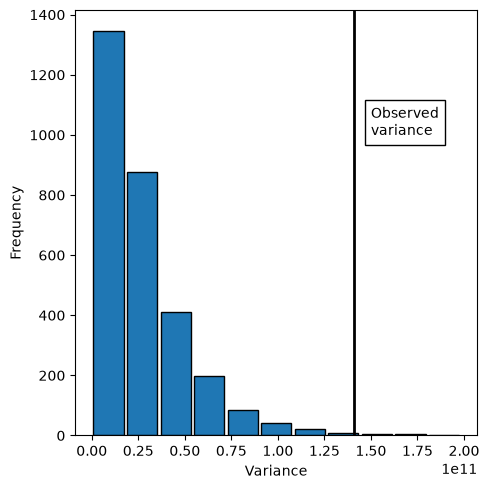

In [135]:
plot_hist(sim_var, obs_var, y_px=1000, x_px=1.5*10**11)

In [143]:
p = (sim_var > obs_var).mean()
print(f'p-value: {p: .6f}')


p-value:  0.003667


* El p-value es < 0.05 con lo cual podemos descartar la hipotesis nula a favor de la hipotesis alternativa. Entonces con un alpha=0.05 concluimos que los metodos son diferentes y que la diferencia no es debida al efectos aleatorios. **OBSERVACION:** Que rechacemos la H0 no quiere decir explicitamente que todos los metodos son diferentes entre si. Puede ocurrir que hay alguno que difiere de los otros simplemente.
* Voy a comparar los metodos sacando `machine`. Es el que mayor diferencia tiene con el resto en la media

In [146]:
obs_var_mod = pensim_mod_permt[pensim_mod_permt['cat'] != 'machine'].groupby('cat').mean().var().iloc[0]

obs_var_mod

np.float64(26379141543.370377)

In [ ]:
sim_var_mod = pd.Series([permutation_test_anova(pensim_mod_permt[pensim_mod_permt['cat'] != 'machine']) for _ in range(3000)])

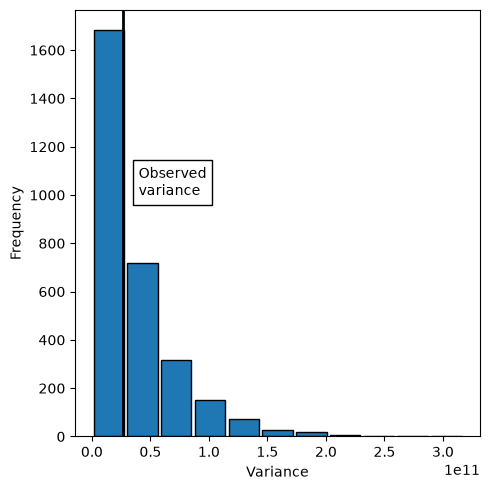

In [196]:
plot_hist(sim_var_mod, obs_var_mod, y_px=1000, x_px=.4*10**11)

In [149]:
p_mod = (sim_var_mod > obs_var_mod).mean()
print(f'p-value: {p_mod: .6f}')

p-value:  0.472333


* Ahora si vemos que realmente la diferencia esta entre machine y el resto de metodos.
* Realmente esta forma de abajo compara `machine` contra el resto de grupos, que los agrupo en una sola categoria `other` y vemos que la diferencia es **extremadamente notable** debido al p-value que obtenemos.

In [ ]:
tmp = pensim_mod_permt.assign(cat=lambda d: np.where(d['cat']=='machine', 'machine', 'other'))

obs_var_machine = tmp.groupby('cat').mean().var().iloc[0]

sim_var_machine = pd.Series([permutation_test_anova(tmp) for _ in range(10000)])

p_machine = (sim_var_machine > obs_var_machine).mean()
print(f'p-value: {p_machine: .4f}')


p-value:  0.0000


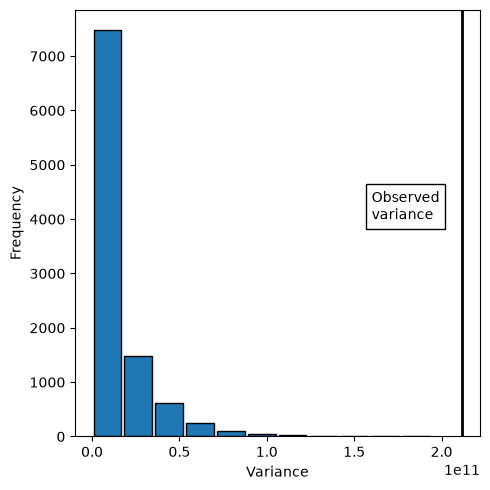

In [173]:
plot_hist(sim_var_machine, obs_var_machine, y_px=4000, x_px=1.6*10**11)

# Calculo de Sample Size y Power

In [284]:
person = x.loc[x['cat'] == 'person', 'pen_total']
machine = x.loc[x['cat'] == 'machine', 'pen_total']

In [285]:
pooled_std = np.sqrt(((len(machine)-1)*machine.var(ddof=1) + (len(person)-1)*person.var(ddof=1)) / (len(machine)+len(person)-2))
effect_size = (machine.mean() - person.mean()) / pooled_std

analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.8, alternative='larger')
print('Sample Size: %.3f' % result)


Sample Size: 8.886


In [286]:
# diferencia minima que te importa detectar (definila vos, ej. 100000 kg)
min_diff = 100000

effect_size_small = min_diff / pooled_std

n_needed = analysis.solve_power(effect_size=effect_size_small, alpha=0.05, power=0.8, alternative='larger')
print(f'Batches necesarios por grupo: {np.ceil(n_needed):.0f}')


Batches necesarios por grupo: 346
